# 01 — Exploration des données NILM

**Objectif.** Comprendre ce qu'il y a *réellement* dans les datasets avant tout modèle :
inventaire des appareils, fréquences d'échantillonnage effectives, qualité du signal,
statistiques par appareil, bilan énergétique. La sortie attendue est un **set d'appareils
cibles** et une **décision de split inter-foyers**, qui conditionneront tout le reste du projet.

On se concentre sur **UK-DALE** (terrain de jeu principal) et **REDD** (validation inter-dataset).
iAWE est gardé de côté comme test de robustesse final et n'est pas exploré en profondeur ici.

> **Note méthodologique.** Certaines analyses nécessitent de *charger* les données
> (qualité, statistiques, bilan). UK-DALE house 1 = ~4 ans à 6 s : tout charger serait
> inutilement lourd. On travaille donc sur une **fenêtre d'analyse** par maison
> (`ANALYSIS_WINDOW_DAYS`), ce qui est un choix assumé et documenté. Les décisions finales
> de prétraitement (notebook 02) devront tenir compte de la plage complète.

## 0 — Configuration et imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter, defaultdict
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nilmtk
from nilmtk import DataSet

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"NILMTK {nilmtk.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

NILMTK 0.4.0.dev1+git.1b324df | pandas 2.2.3 | numpy 2.4.5


In [2]:
DATA_DIR = Path("../data")

DATASETS = {
    "UK-DALE": DATA_DIR / "ukdale.h5",
    "REDD":    DATA_DIR / "redd.h5",
    # "iAWE":  DATA_DIR / "iawe.h5",   # gardé pour le test de robustesse final
}

# Fenetre d'analyse par maison pour les calculs qui chargent les donnees.
ANALYSIS_WINDOW_DAYS = 14      # duree de la fenetre par maison
STATS_SAMPLE_PERIOD  = 6       # secondes : resampling commun pour comparer les datasets

ARTIFACTS_DIR = Path("../outputs/exploration")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Fenetre d'analyse :", ANALYSIS_WINDOW_DAYS, "jours")
print("Resampling stats   :", STATS_SAMPLE_PERIOD, "s")
print("Artefacts          :", ARTIFACTS_DIR.resolve())

Fenetre d'analyse : 14 jours
Resampling stats   : 6 s
Artefacts          : C:\Users\acret\Documents\Ponts 2A\Semestre 2\Projet_scientifique\projet-nilm\outputs\exploration


In [3]:
datasets = {}
for name, path in DATASETS.items():
    if path.exists():
        datasets[name] = DataSet(str(path))
        print(f"OK   {name:8s} <- {path}")
    else:
        print(f"MISS {name:8s} introuvable : {path}")

OK   UK-DALE  <- ..\data\ukdale.h5
OK   REDD     <- ..\data\redd.h5


In [4]:
# Helpers reutilises partout

def get_app_type(app):
    # nom de categorie d'un appareil ('fridge', 'washing machine', ...)
    try:
        return app.identifier.type
    except Exception:
        try:
            return app.type.get("type", "unknown")
        except Exception:
            return "unknown"

def get_app_instance(app):
    try:
        return app.identifier.instance
    except Exception:
        return None

def set_house_window(ds, house_id, days):
    # cale la fenetre sur le timeframe du MAINS (pas du groupe : un sous-compteur
    # peut demarrer bien avant le mains, ce qui creerait une fenetre vide cote mains)
    try:
        ds.set_window(start=None, end=None)
    except Exception:
        pass
    mains = ds.buildings[house_id].elec.mains()
    tf = mains.get_timeframe()
    start, end = tf.start, tf.end
    if start is None or pd.isna(start):
        return start, end
    if end is None or pd.isna(end):
        end = start + pd.Timedelta(days=days)
    else:
        end = min(end, start + pd.Timedelta(days=days))
    ds.set_window(start=start.strftime("%Y-%m-%d %H:%M:%S"),
                  end=end.strftime("%Y-%m-%d %H:%M:%S"))
    return start, end

def reset_windows():
    for ds in datasets.values():
        try:
            ds.set_window(start=None, end=None)
        except Exception:
            pass

def find_meters_for_type(elec, app_type):
    """Meters dont AU MOINS un appareil a EXACTEMENT ce type.
    Evite le matching flou de elec[app_type] qui renvoie une categorie voisine."""
    out = []
    for meter in elec.submeters().meters:
        if any(get_app_type(app) == app_type for app in meter.appliances):
            out.append(meter)
    return out

print("Helpers definis.")

Helpers definis.


## 1 — Vue d'ensemble

Plages temporelles, nombre d'appareils et de sous-compteurs par maison.
C'est la version enrichie de ce que tu avais déjà dans `00_test_setup`.

In [5]:
reset_windows()
rows = []
for ds_name, ds in datasets.items():
    for house_id in sorted(ds.buildings.keys()):
        elec = ds.buildings[house_id].elec
        try:
            tf = elec.mains().get_timeframe()           # mains, pas le groupe
            start, end = tf.start, tf.end
            duration_days = (end - start).days if (start is not None and end is not None) else np.nan
        except Exception:
            start = end = None; duration_days = np.nan
        rows.append({
            "dataset": ds_name, "house": house_id,
            "start": None if start is None else start.date(),
            "end":   None if end is None else end.date(),
            "duration_days": duration_days,
            "n_appliances": len(elec.appliances),
            "n_submeters": len(elec.submeters().meters),
        })
overview = pd.DataFrame(rows)
overview

,dataset,house,start,end,duration_days,n_appliances,n_submeters
0,UK-DALE,1,2013-03-17,2017-04-26,1500,72,52
1,UK-DALE,2,2013-04-16,2013-10-10,176,18,18
2,UK-DALE,3,2013-02-27,2013-04-08,39,4,4
3,UK-DALE,4,2013-03-09,2013-10-01,205,11,5
4,UK-DALE,5,2014-06-29,2014-11-13,137,24,24
5,REDD,1,2011-04-18,2011-05-24,36,16,16
6,REDD,2,2011-04-17,2011-05-22,35,9,9
7,REDD,3,2011-04-16,2011-05-30,44,19,19
8,REDD,4,2011-04-16,2011-06-03,47,17,17
9,REDD,5,2011-04-18,2011-05-31,43,22,22


## 2 — Inventaire des appareils

Quels types d'appareils sont monitorés, et **dans combien de maisons** ? C'est le point
décisif pour le protocole inter-foyers : on ne peut entraîner/tester un modèle que sur des
appareils présents dans plusieurs maisons.

⚠️ **Piège de nommage.** Les datasets utilisent des conventions différentes
(`fridge` vs `fridge freezer` vs `refrigerator`). La matrice ci-dessous expose ces variantes
brutes — il faudra décider lesquelles regrouper.

In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def appliance_type_counts(elec):
    c = Counter()
    for app in elec.appliances:
        c[get_app_type(app)] += 1
    return c

presence = defaultdict(dict)
for ds_name, ds in datasets.items():
    for house_id in sorted(ds.buildings.keys()):
        elec = ds.buildings[house_id].elec
        col = f"{ds_name}_h{house_id}"
        for app_type, n in appliance_type_counts(elec).items():
            presence[app_type][col] = n

presence_df = pd.DataFrame(presence).T.fillna(0).astype(int)
presence_df = presence_df.reindex(sorted(presence_df.columns), axis=1)
presence_df["n_houses"] = (presence_df > 0).sum(axis=1)
presence_df = presence_df.sort_values("n_houses", ascending=False)
presence_df

,REDD_h1,REDD_h2,REDD_h3,REDD_h4,REDD_h5,REDD_h6,UK-DALE_h1,UK-DALE_h2,UK-DALE_h3,UK-DALE_h4,UK-DALE_h5,n_houses
dish washer,1,1,1,1,1,1,1,1,0,0,1,9
microwave,1,1,1,0,1,0,1,1,0,1,1,8
light,3,1,5,4,5,1,16,0,0,1,0,8
washer dryer,1,1,1,1,1,1,2,0,0,0,1,8
fridge,1,1,1,0,1,1,0,1,0,0,0,6
sockets,4,2,5,3,6,4,0,0,0,0,0,6
kettle,0,0,0,0,0,0,1,1,1,1,1,5
unknown,2,0,1,3,1,1,0,0,0,0,0,5
electric stove,1,1,0,1,0,1,0,0,0,0,1,5
electric space heater,1,0,0,0,1,1,0,0,1,0,0,4


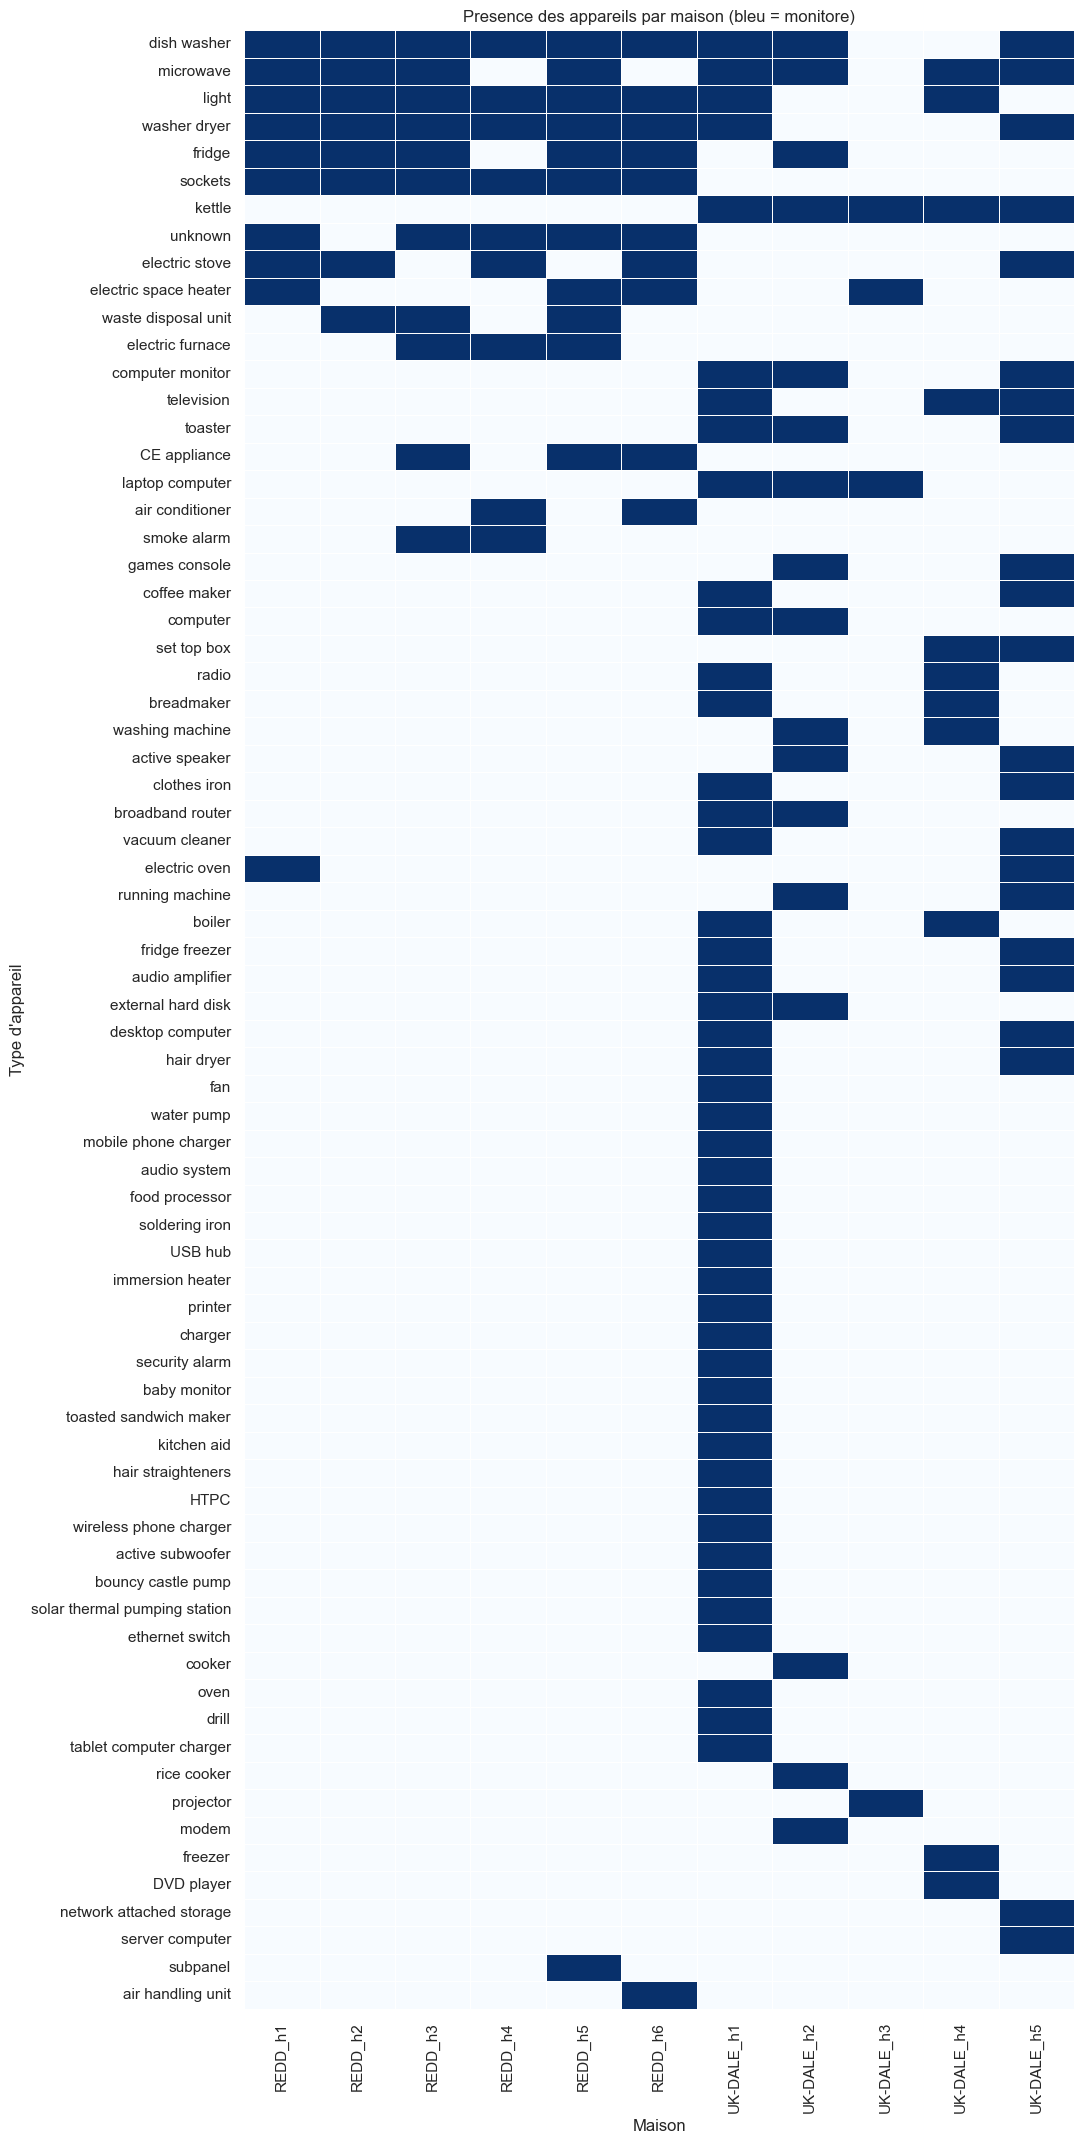

In [7]:
mat = (presence_df.drop(columns="n_houses") > 0).astype(int)
fig, ax = plt.subplots(figsize=(11, max(5, 0.30 * len(mat))))
sns.heatmap(mat, cmap="Blues", cbar=False, linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Presence des appareils par maison (bleu = monitore)")
ax.set_xlabel("Maison"); ax.set_ylabel("Type d'appareil")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "presence_appareils.png", dpi=120)
plt.show()

In [8]:
# Appareils candidats classiques de la litterature NILM.
# On les compare a la presence reelle pour reperer les variantes de nommage.
TARGET_CANDIDATES = [
    "fridge", "fridge freezer", "freezer", "refrigerator",
    "washing machine", "washer dryer",
    "dish washer", "dishwasher",
    "microwave",
    "kettle",
]
present_candidates = presence_df[presence_df.index.isin(TARGET_CANDIDATES)]
present_candidates

,REDD_h1,REDD_h2,REDD_h3,REDD_h4,REDD_h5,REDD_h6,UK-DALE_h1,UK-DALE_h2,UK-DALE_h3,UK-DALE_h4,UK-DALE_h5,n_houses
dish washer,1,1,1,1,1,1,1,1,0,0,1,9
microwave,1,1,1,0,1,0,1,1,0,1,1,8
washer dryer,1,1,1,1,1,1,2,0,0,0,1,8
fridge,1,1,1,0,1,1,0,1,0,0,0,6
kettle,0,0,0,0,0,0,1,1,1,1,1,5
washing machine,0,0,0,0,0,0,0,1,0,1,0,2
fridge freezer,0,0,0,0,0,0,1,0,0,0,1,2
freezer,0,0,0,0,0,0,0,0,0,1,0,1


## 3 — Fréquences d'échantillonnage effectives

Les valeurs annoncées (UK-DALE « 1/6 Hz », REDD « 1 Hz ») sont des moyennes : la résolution
réelle varie selon les sous-compteurs et les maisons. On lit la période d'échantillonnage
de chaque meter, puis on résume par dataset.

In [9]:
def meter_sample_period(meter):
    try:
        sp = meter.sample_period()
        if sp:
            return float(sp)
    except Exception:
        pass
    return np.nan

def iter_meters(meter_or_group):
    # gere mains() qui peut etre un ElecMeter (UK-DALE) ou un MeterGroup multi-phases (REDD)
    if hasattr(meter_or_group, "meters"):
        return list(meter_or_group.meters)
    return [meter_or_group]

sp_rows = []
for ds_name, ds in datasets.items():
    for house_id in sorted(ds.buildings.keys()):
        elec = ds.buildings[house_id].elec
        for meter in iter_meters(elec.mains()):
            sp_rows.append({"dataset": ds_name, "house": house_id, "meter": "mains",
                            "label": meter.label(), "sample_period_s": meter_sample_period(meter)})
        for meter in elec.submeters().meters:
            sp_rows.append({"dataset": ds_name, "house": house_id, "meter": "submeter",
                            "label": meter.label(), "sample_period_s": meter_sample_period(meter)})

sp_df = pd.DataFrame(sp_rows)
sp_summary = sp_df.groupby(["dataset", "meter"])["sample_period_s"].agg(["min", "median", "max", "count"])
sp_summary

min  median  max  count
dataset meter                            
REDD    mains     1.0     1.0  1.0     12
        submeter  3.0     3.0  3.0     97
UK-DALE mains     1.0     1.0  6.0      5
        submeter  6.0     6.0  6.0    103

## 4 — Qualité du signal

`get_timeframe()` donne les bornes, pas les **trous au milieu**. On mesure ici :
- le **taux de dropout** des mains (fraction de données manquantes sur la fenêtre),
- le nombre de **sections continues** (`good_sections`) et la durée de la plus longue.

Calculé sur la fenêtre d'analyse par maison (pas sur toute la plage).

In [10]:
quality_rows = []
for ds_name, ds in datasets.items():
    for house_id in sorted(ds.buildings.keys()):
        start, end = set_house_window(ds, house_id, ANALYSIS_WINDOW_DAYS)
        mains = ds.buildings[house_id].elec.mains()
        try:
            dropout = float(mains.dropout_rate())
        except Exception:
            dropout = np.nan
        try:
            good = mains.good_sections()
            n_good = len(good)
            longest_h = max((g.timedelta.total_seconds() for g in good), default=0) / 3600.0
        except Exception:
            n_good, longest_h = np.nan, np.nan
        quality_rows.append({
            "dataset": ds_name, "house": house_id,
            "window_start": start.date(), "window_end": end.date(),
            "mains_dropout_rate": round(dropout, 4) if dropout == dropout else np.nan,
            "n_good_sections": n_good,
            "longest_good_section_h": round(longest_h, 1) if longest_h == longest_h else np.nan,
        })

reset_windows()
quality_df = pd.DataFrame(quality_rows)
quality_df

Calculating dropout_rate for ElecMeterID(instance=2, building=6, dataset='REDD') ...   

,dataset,house,window_start,window_end,mains_dropout_rate,n_good_sections,longest_good_section_h
0,UK-DALE,1,2013-03-17,2013-03-31,0.0029,5,167.9
1,UK-DALE,2,2013-04-16,2013-04-30,0.0000,8,116.3
2,UK-DALE,3,2013-02-27,2013-03-13,0.0217,42,41.1
3,UK-DALE,4,2013-03-09,2013-03-23,0.0272,1,336.0
4,UK-DALE,5,2014-06-29,2014-07-13,0.0000,29,73.0
5,REDD,1,2011-04-18,2011-05-02,0.0001,15,54.1
6,REDD,2,2011-04-17,2011-05-01,0.0050,24,93.7
7,REDD,3,2011-04-16,2011-04-30,0.0430,183,48.0
8,REDD,4,2011-04-16,2011-04-30,0.0004,22,54.2
9,REDD,5,2011-04-18,2011-05-02,0.0069,23,12.0


## 5 — Statistiques par appareil

Pour les appareils candidats : seuil ON/OFF, nombre d'activations sur la fenêtre, durée
moyenne d'un cycle, puissance moyenne quand l'appareil est ON. Ces chiffres serviront à
fixer les seuils de détection (F1) et à comprendre la « difficulté » de chaque appareil.

> Le nombre d'activations est compté **sur une fenêtre de `ANALYSIS_WINDOW_DAYS` jours**,
> identique pour toutes les maisons : les comptes sont donc comparables entre elles.

In [11]:
def appliance_activation_stats(meter, sample_period):
    try:
        thr = float(meter.on_power_threshold())
    except Exception:
        thr = 10.0
    try:
        activations = meter.get_activations(sample_period=sample_period)
    except TypeError:
        activations = meter.get_activations()
    except Exception:
        return None
    if not activations:
        return {"on_power_threshold_W": round(thr, 1), "n_activations": 0,
                "mean_duration_min": np.nan, "mean_on_power_W": np.nan}
    durations = [(a.index[-1] - a.index[0]).total_seconds() / 60.0 for a in activations]
    powers = [float(a.mean()) for a in activations]
    return {"on_power_threshold_W": round(thr, 1), "n_activations": len(activations),
            "mean_duration_min": round(float(np.mean(durations)), 1),
            "mean_on_power_W": round(float(np.mean(powers)), 1)}

TARGETS_FOR_STATS = present_candidates.index.tolist()

stat_rows = []
for ds_name, ds in datasets.items():
    for house_id in sorted(ds.buildings.keys()):
        set_house_window(ds, house_id, ANALYSIS_WINDOW_DAYS)
        elec = ds.buildings[house_id].elec
        for app_type in TARGETS_FOR_STATS:
            meters = find_meters_for_type(elec, app_type)   # match EXACT
            if not meters:
                continue
            s = appliance_activation_stats(meters[0], STATS_SAMPLE_PERIOD)
            if s is None:
                continue
            s.update({"dataset": ds_name, "house": house_id, "appliance": app_type})
            stat_rows.append(s)

reset_windows()
stats_df = pd.DataFrame(stat_rows)
if len(stats_df):
    stats_df = stats_df[["dataset", "house", "appliance", "on_power_threshold_W",
                         "n_activations", "mean_duration_min", "mean_on_power_W"]]
stats_df

Loading data for meter ElecMeterID(instance=20, building=1, dataset='REDD')     
Done loading data all meters for this chunk.
Loading data for meter ElecMeterID(instance=14, building=3, dataset='REDD')     
Done loading data all meters for this chunk.
Loading data for meter ElecMeterID(instance=9, building=5, dataset='REDD')     
Done loading data all meters for this chunk.


,dataset,house,appliance,on_power_threshold_W,n_activations,mean_duration_min,mean_on_power_W
0,UK-DALE,1,dish washer,10.0,4,82.7,550.1
1,UK-DALE,1,microwave,200.0,70,0.9,894.3
2,UK-DALE,1,washer dryer,20.0,6,115.7,539.9
3,UK-DALE,1,kettle,10.0,61,2.3,2000.2
4,UK-DALE,1,fridge freezer,50.0,330,21.3,95.5
5,UK-DALE,2,dish washer,10.0,0,NaN,NaN
6,UK-DALE,2,microwave,200.0,0,NaN,NaN
7,UK-DALE,2,fridge,50.0,0,NaN,NaN
8,UK-DALE,2,kettle,2000.0,94,3.2,2678.2
9,UK-DALE,2,washing machine,20.0,0,NaN,NaN


### 5.1 — Signatures visuelles

Un coup d'œil aux formes d'onde aide à comprendre pourquoi certains appareils sont faciles
(kettle : pic franc) et d'autres difficiles (lave-linge : cycle long et variable).

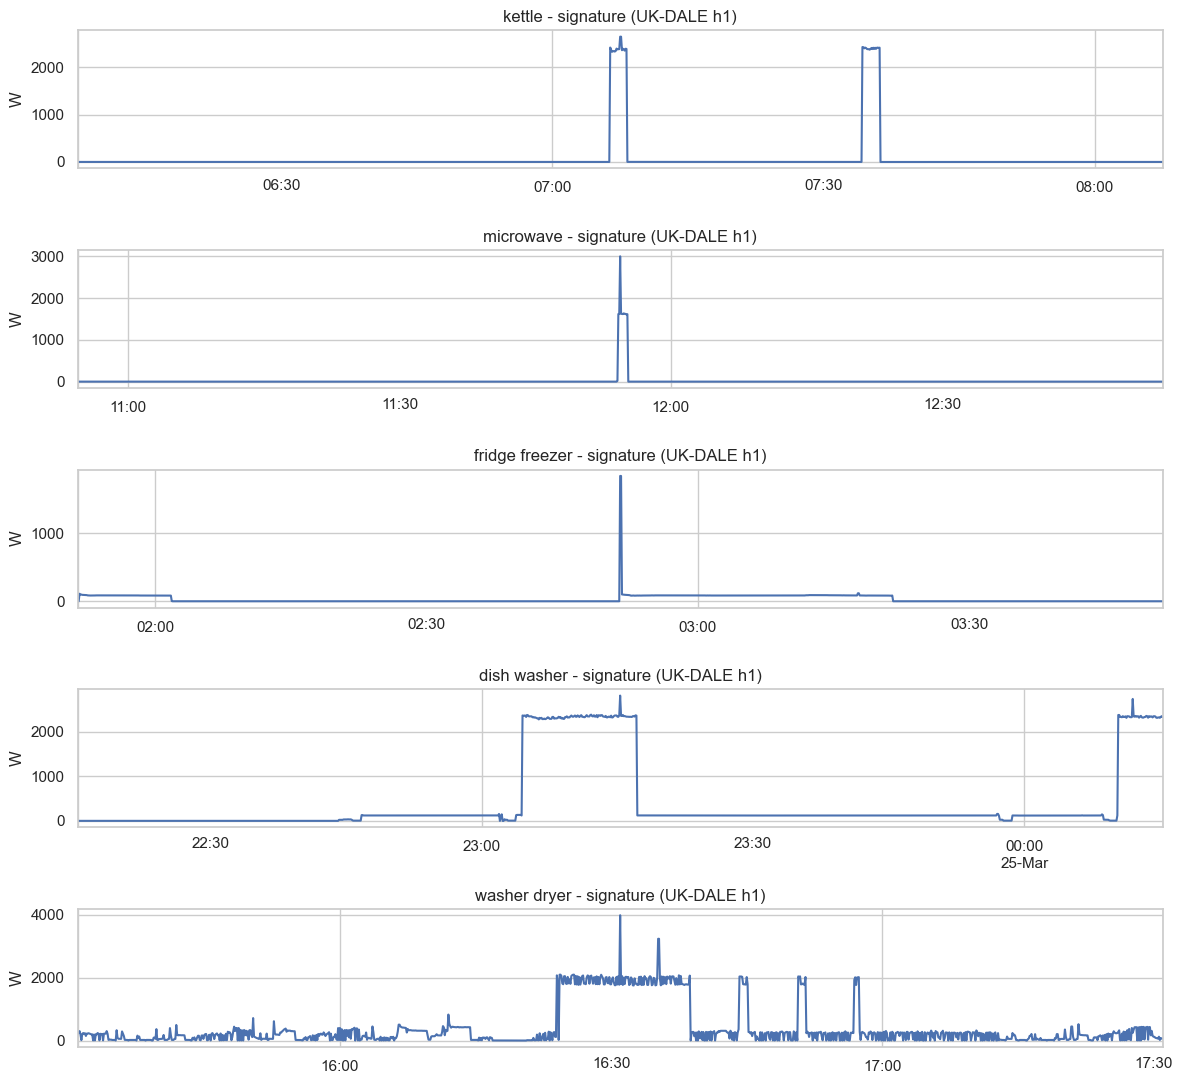

In [12]:
ds = datasets["UK-DALE"]; house_id = 1
set_house_window(ds, house_id, ANALYSIS_WINDOW_DAYS)
elec = ds.buildings[house_id].elec

candidates = ["kettle", "microwave", "fridge", "fridge freezer", "dish washer",
              "washing machine", "washer dryer"]
apps_to_plot = [t for t in candidates if find_meters_for_type(elec, t)][:5]

if apps_to_plot:
    fig, axes = plt.subplots(len(apps_to_plot), 1, figsize=(12, 2.2 * len(apps_to_plot)))
    if len(apps_to_plot) == 1: axes = [axes]
    for ax, app in zip(axes, apps_to_plot):
        try:
            meter = find_meters_for_type(elec, app)[0]
            s = meter.power_series_all_data(sample_period=STATS_SAMPLE_PERIOD)
            if s is None or len(s) == 0:
                ax.set_title(f"{app} - aucune donnee dans la fenetre"); continue
            s = s.dropna()
            peak = s.idxmax()
            s.loc[peak - pd.Timedelta("1h"): peak + pd.Timedelta("1h")].plot(ax=ax)
            ax.set_title(f"{app} - signature (UK-DALE h1)"); ax.set_ylabel("W")
        except Exception as e:
            ax.set_title(f"{app} - indisponible ({e})")
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "signatures_appareils.png", dpi=120)
    plt.show()
reset_windows()

## 6 — Bilan énergétique

Quelle fraction de l'énergie totale est expliquée par les sous-compteurs ? Le complément
(1 − proportion) correspond aux appareils **non monitorés** : c'est le bruit résiduel
irréductible que la désagrégation devra absorber. Une proportion faible = problème plus dur.

balance_rows = []
for ds_name, ds in datasets.items():
    for house_id in sorted(ds.buildings.keys()):
        set_house_window(ds, house_id, ANALYSIS_WINDOW_DAYS)
        elec = ds.buildings[house_id].elec
        try:
            prop = float(elec.proportion_of_energy_submetered())
        except Exception:
            prop = np.nan
        balance_rows.append({
            "dataset": ds_name, "house": house_id,
            "proportion_submetered": round(prop, 3) if prop == prop else np.nan,
            "energie_non_monitoree": round(1 - prop, 3) if prop == prop else np.nan,
        })

reset_windows()
balance_df = pd.DataFrame(balance_rows)
balance_df

In [13]:
BALANCE_WINDOW_DAYS = 3   # le ratio submetered est stable, 3 jours suffisent

balance_rows = []
for ds_name, ds in datasets.items():
    for house_id in sorted(ds.buildings.keys()):
        set_house_window(ds, house_id, BALANCE_WINDOW_DAYS)
        elec = ds.buildings[house_id].elec
        try:
            prop = float(elec.proportion_of_energy_submetered())
        except Exception:
            prop = np.nan
        balance_rows.append({
            "dataset": ds_name, "house": house_id,
            "proportion_submetered": round(prop, 3) if prop == prop else np.nan,
            "energie_non_monitoree": round(1 - prop, 3) if prop == prop else np.nan,
        })
reset_windows()
balance_df = pd.DataFrame(balance_rows)
balance_df

Running MeterGroup.proportion_of_energy_submetered...
Running MeterGroup.proportion_of_energy_submetered...
Running MeterGroup.proportion_of_energy_submetered...
Running MeterGroup.proportion_of_energy_submetered...
Running MeterGroup.proportion_of_energy_submetered...
Running MeterGroup.proportion_of_energy_submetered...
Calculating total_energy for ElecMeterID(instance=2, building=1, dataset='REDD') ...   Running MeterGroup.proportion_of_energy_submetered...
Calculating total_energy for ElecMeterID(instance=2, building=2, dataset='REDD') ...   Running MeterGroup.proportion_of_energy_submetered...
Calculating total_energy for ElecMeterID(instance=2, building=3, dataset='REDD') ...   Running MeterGroup.proportion_of_energy_submetered...
Calculating total_energy for ElecMeterID(instance=2, building=4, dataset='REDD') ...   Running MeterGroup.proportion_of_energy_submetered...
Calculating total_energy for ElecMeterID(instance=2, building=5, dataset='REDD') ...   Running MeterGroup.propor

,dataset,house,proportion_submetered,energie_non_monitoree
0,UK-DALE,1,0.801,0.199
1,UK-DALE,2,0.401,0.599
2,UK-DALE,3,0.153,0.847
3,UK-DALE,4,0.293,0.707
4,UK-DALE,5,0.796,0.204
5,REDD,1,0.835,0.165
6,REDD,2,0.570,0.430
7,REDD,3,0.865,0.135
8,REDD,4,0.556,0.444
9,REDD,5,0.844,0.156


## 7 — Décisions

**À ajuster après lecture des résultats ci-dessus.** C'est le livrable de ce notebook :
le set d'appareils cibles et le protocole de split, qui seront figés et réutilisés partout.

Critères de choix des appareils cibles :
- présents dans **plusieurs maisons** (cf. section 2),
- signature **distincte** (cf. 5.1),
- couvrir des **profils variés** : continu (frigo), cyclique long (lave-linge, lave-vaisselle),
  bref et intense (kettle, micro-ondes).

Pour le split inter-foyers : **train et test sur des maisons disjointes** — c'est le seul
protocole honnête pour mesurer la généralisation, qui est l'enjeu industriel réel.

In [16]:
# >>> Decisions finales (appuyees sur la section 2, fiable) <

# Cibles canoniques + variantes de nommage a regrouper selon les datasets.
APPLIANCE_ALIASES = {
    "fridge":          ["fridge", "fridge freezer", "freezer", "refrigerator"],
    "washing machine": ["washing machine", "washer dryer"],
    "dish washer":     ["dish washer", "dishwasher"],
    "microwave":       ["microwave"],
    "kettle":          ["kettle"],   # UK-DALE uniquement : exclure des essais inter-dataset
}
TARGET_APPLIANCES = list(APPLIANCE_ALIASES.keys())

# Cibles utilisables en cross-dataset (REDD n'a pas de kettle)
CROSS_DATASET_TARGETS = ["fridge", "washing machine", "dish washer", "microwave"]

# Split inter-foyers. h1, h2, h5 contiennent les 5 categories cibles (cf. section 2)
# h1 : riche (tous sauf que fridge etiquete 'fridge freezer'). h2 : kettle quasi uniquement.
# h4 : appoint (freezer, microwave, washing machine, kettle ; pas de dishwasher).
# h5 : test (toutes cibles presentes, maison la plus propre : 0% dropout, 80% submetered).
# h3 exclue (kettle seul, 4 appareils, 15% submetered).
SPLIT_UKDALE = {"train": [1, 2, 4], "test": [5]}

# REDD : pour validation inter-dataset. h6 exclue (44% de dropout).
SPLIT_REDD = {"train": [1, 2, 3], "test": [4, 5]}

config = {
    "target_appliances": TARGET_APPLIANCES,
    "appliance_aliases": APPLIANCE_ALIASES,
    "cross_dataset_targets": CROSS_DATASET_TARGETS,
    "split_ukdale": SPLIT_UKDALE,
    "split_redd": SPLIT_REDD,
    "excluded_houses": {"UK-DALE": [3], "REDD": [6]},
    "stats_sample_period_s": STATS_SAMPLE_PERIOD,
    "analysis_window_days": ANALYSIS_WINDOW_DAYS,
    "random_seed": RANDOM_SEED,
}
with open(ARTIFACTS_DIR / "exploration_config.json", "w") as f:
    json.dump(config, f, indent=2, default=str)
print(json.dumps(config, indent=2, default=str))

{
  "target_appliances": [
    "fridge",
    "washing machine",
    "dish washer",
    "microwave",
    "kettle"
  ],
  "appliance_aliases": {
    "fridge": [
      "fridge",
      "fridge freezer",
      "freezer",
      "refrigerator"
    ],
    "washing machine": [
      "washing machine",
      "washer dryer"
    ],
    "dish washer": [
      "dish washer",
      "dishwasher"
    ],
    "microwave": [
      "microwave"
    ],
    "kettle": [
      "kettle"
    ]
  },
  "cross_dataset_targets": [
    "fridge",
    "washing machine",
    "dish washer",
    "microwave"
  ],
  "split_ukdale": {
    "train": [
      1,
      2,
      4
    ],
    "test": [
      5
    ]
  },
  "split_redd": {
    "train": [
      1,
      2,
      3
    ],
    "test": [
      4,
      5
    ]
  },
  "excluded_houses": {
    "UK-DALE": [
      3
    ],
    "REDD": [
      6
    ]
  },
  "stats_sample_period_s": 6,
  "analysis_window_days": 14,
  "random_seed": 42
}


## 8 — Export des tables

On sauvegarde tout en CSV pour réutilisation dans les notebooks suivants (le dossier
`outputs/` est déjà dans ton `.gitignore`).

In [17]:
overview.to_csv(ARTIFACTS_DIR / "overview.csv", index=False)
presence_df.to_csv(ARTIFACTS_DIR / "presence_appareils.csv")
sp_df.to_csv(ARTIFACTS_DIR / "sample_periods.csv", index=False)
quality_df.to_csv(ARTIFACTS_DIR / "qualite_signal.csv", index=False)
if len(stats_df):
    stats_df.to_csv(ARTIFACTS_DIR / "stats_appareils.csv", index=False)
balance_df.to_csv(ARTIFACTS_DIR / "bilan_energetique.csv", index=False)
print("Tables exportees dans", ARTIFACTS_DIR.resolve())

Tables exportees dans C:\Users\acret\Documents\Ponts 2A\Semestre 2\Projet_scientifique\projet-nilm\outputs\exploration


## 9 — Synthèse

Questions :

1. **Appareils cibles retenus** et justification (présence + signature) :
2. **Variantes de nommage** à regrouper (ex. `fridge` / `fridge freezer`) :
3. **Maisons exclues** du split et pourquoi (durée trop courte, appareils manquants) :
4. **Maisons les plus propres** (dropout faible, longues sections continues) :
5. **Appareils les plus difficiles** anticipés (faible puissance, peu d'activations) :
6. **Proportion d'énergie non monitorée** typique → niveau de bruit résiduel attendu :

Réponses : 

1. Cibles : fridge (charge froide regroupée), washing machine, dishwasher, microwave — communes UK-DALE+REDD — plus kettle (UK-DALE uniquement, REDD n'en a aucun ; signature la plus propre du lot).
2. Regroupements : fridge freezer+freezer→fridge ; washer dryer→washing machine ; dishwasher→dish washer. Choix discutable pour congélateur≠frigo, à raffiner si besoin.
3. Maisons exclues : UK-DALE h3 (kettle seul, 4 appareils, 15 % submetered) ; REDD h6 (44 % dropout, 32 % submetered). h2 conservée mais quasi mono-appareil (kettle) sur sa fenêtre.
4. Maisons les plus propres : UK-DALE h5 (0 % dropout, 80 % submetered) et h2 (0 % dropout) ; REDD h1/h4 (dropout < 0.05 %).
5. Appareils les plus durs (anticipé) : dishwasher (1-7 activations/14 j → très peu d'exemples, le plus fragile) ; microwave (très bref, 0.9-3.5 min). Le fridge sera le plus facile (300-400 activations, profil régulier).
6. Énergie non monitorée : 16-20 % sur les bonnes maisons (UK-DALE h1/h5, REDD h1/h3/h5) → bruit résiduel modéré et favorable. Très élevé sur UK-DALE h3/h4 (71-85 %), ce qui les disqualifie.